<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Notebook Section
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Imports and Setup
  </h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import gc
sys.path.append(os.path.abspath(".."))
from utilities import engin_creator
import warnings as w
w.filterwarnings('ignore')

In [2]:
engin = engin_creator()

In [3]:
'''aisel_query = 'SELECT * FROM aisles'
df_aisel = pd.read_sql(aisel_query, engin)

department_query = 'SELECT * FROM departments'
df_department = pd.read_sql(department_query, engin)

order_product_train = 'SELECT * FROM order_products__train'
df_opt = pd.read_sql(order_product_train, engin)

order_query = 'SELECT * FROM orders'
df_order = pd.read_sql(order_query, engin)

products_query = 'SELECT * FROM products'
df_products = pd.read_sql(products_query, engin)'''

"aisel_query = 'SELECT * FROM aisles'\ndf_aisel = pd.read_sql(aisel_query, engin)\n\ndepartment_query = 'SELECT * FROM departments'\ndf_department = pd.read_sql(department_query, engin)\n\norder_product_train = 'SELECT * FROM order_products__train'\ndf_opt = pd.read_sql(order_product_train, engin)\n\norder_query = 'SELECT * FROM orders'\ndf_order = pd.read_sql(order_query, engin)\n\nproducts_query = 'SELECT * FROM products'\ndf_products = pd.read_sql(products_query, engin)"

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Imports and Setup
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Loading Files
  </h2>
</div>

In [4]:
aisles_df = pd.read_csv('/home/korty/Code_House/VS_CODE/INSTAMART/Files/Database_Inhibitor/aisles.csv')
order_df = pd.read_csv('/home/korty/Code_House/VS_CODE/INSTAMART/Files/Database_Inhibitor/orders.csv')
department_df = pd.read_csv('/home/korty/Code_House/VS_CODE/INSTAMART/Files/Database_Inhibitor/departments.csv')
product_df = pd.read_csv('/home/korty/Code_House/VS_CODE/INSTAMART/Files/Database_Inhibitor/products.csv')
order_products_prior = pd.read_csv('/home/korty/Code_House/VS_CODE/INSTAMART/Files/Database_Inhibitor/order_products__prior.csv',nrows=15_000_000)

In [5]:
#### FETCHING THE TABELS FROM DATABASE TAKES "71.6" SECONDS AND DIRECTLY LOADING CSV FILES ONLY TAKES "13.7" SECONDS.
#### DIRECT APPROCH IS 80.9% FASTER THAN DATABASE APPROCH, SO TO SAVE TIME I WILL BE DIRECTLY FETCHING THE CSV.
#### I HAVE SHOWN HOW YOU CAN FETCH THE DATA DIRECTLY FROM DATABASE THO.

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Data Preparation
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Data Cleaning and Error Checks
  </h2>
</div>

In [6]:
def table_lookout(name, df):
    print("=" * 60)
    print(f"Table Name      : {name.upper()}")
    print(f"Table Shape     : {df.shape}")
    print(f"Rows            : {df.shape[0]}")
    print(f"Columns         : {df.shape[1]}")
    print("\nColumn Names:")
    print(df.columns.tolist())
    print("\nNull Values:")
    print(df.isna().sum())
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    print("\nData Types:")
    df.info()
    print("\nSummary Statistics:")
    print(df.describe(include='all'))
    print("\nFirst 5 Rows:")
    print(df.head())
    print("=" * 60)


In [7]:
table_lookout('aisles',aisles_df)

Table Name      : AISLES
Table Shape     : (134, 2)
Rows            : 134
Columns         : 2

Column Names:
['aisle_id', 'aisle']

Null Values:
aisle_id    0
aisle       0
dtype: int64

Duplicate Rows: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB

Summary Statistics:
          aisle_id                  aisle
count   134.000000                    134
unique         NaN                    134
top            NaN  prepared soups salads
freq           NaN                      1
mean     67.500000                    NaN
std      38.826537                    NaN
min       1.000000                    NaN
25%      34.250000                    NaN
50%      67.500000                    NaN
75%     100.750000                 

In [8]:
table_lookout('department',department_df)

Table Name      : DEPARTMENT
Table Shape     : (21, 2)
Rows            : 21
Columns         : 2

Column Names:
['department_id', 'department']

Null Values:
department_id    0
department       0
dtype: int64

Duplicate Rows: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes

Summary Statistics:
        department_id department
count       21.000000         21
unique            NaN         21
top               NaN     frozen
freq              NaN          1
mean        11.000000        NaN
std          6.204837        NaN
min          1.000000        NaN
25%          6.000000        NaN
50%         11.000000        NaN
75%         16.000000        NaN
max         21.000000        NaN

First 5 Rows:

In [9]:
table_lookout('order',order_df)

Table Name      : ORDER
Table Shape     : (3421083, 7)
Rows            : 3421083
Columns         : 7

Column Names:
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Null Values:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Duplicate Rows: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(

In [10]:
table_lookout('products',product_df)

Table Name      : PRODUCTS
Table Shape     : (49688, 4)
Rows            : 49688
Columns         : 4

Column Names:
['product_id', 'product_name', 'aisle_id', 'department_id']

Null Values:
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Duplicate Rows: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

Summary Statistics:
          product_id                product_name      aisle_id  department_id
count   49688.000000                       49688  49688.000000   49688.000000
unique           NaN                       49688           NaN            NaN
top              Na

In [11]:
table_lookout('order products prior',order_products_prior)

Table Name      : ORDER PRODUCTS PRIOR
Table Shape     : (15000000, 4)
Rows            : 15000000
Columns         : 4

Column Names:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Null Values:


order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

Duplicate Rows: 0

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000000 entries, 0 to 14999999
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 457.8 MB

Summary Statistics:
           order_id    product_id  add_to_cart_order     reordered
count  1.500000e+07  1.500000e+07       1.500000e+07  1.500000e+07
mean   7.916492e+05  2.557920e+04       8.350932e+00  5.900281e-01
std    4.570286e+05  1.409838e+04       7.124013e+00  4.918282e-01
min    2.000000e+00  1.000000e+00       1.000000e+00  0.000000e+00
25%    3.960720e+05  1.352900e+04       3.000000e+00  0.000000e+00
50%    7.917000e+05  2.525600e+04       6.000000e+00  1.000000e+00
75%    1.187745e+06  3.794000e+04      

In [12]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [13]:
order_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [14]:
df= order_df[(order_df.iloc[:,-1].isna()) & (order_df.loc[:,'user_id'] == 1)]
df.shape

(1, 7)

In [15]:
order_df['days_since_prior_order'] = order_df['days_since_prior_order'].fillna(0)
order_df['days_since_prior_order'] = order_df['days_since_prior_order'].astype(int)

In [16]:
order_df.head()
# shorted wiht this one
order_df.isna().sum()
# indeed sorted

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

In [17]:
department_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [18]:
department_df.nunique()
department_df.value_counts()
# sorted and 21 depts

department_id  department     
1              frozen             1
2              other              1
3              bakery             1
4              produce            1
5              alcohol            1
6              international      1
7              beverages          1
8              pets               1
9              dry goods pasta    1
10             bulk               1
11             personal care      1
12             meat seafood       1
13             pantry             1
14             breakfast          1
15             canned goods       1
16             dairy eggs         1
17             household          1
18             babies             1
19             snacks             1
20             deli               1
21             missing            1
Name: count, dtype: int64

In [19]:
product_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [20]:
product_df.nunique()
# match perfectly with dept id form dept table and aisels id count with aisle relation

product_id       49688
product_name     49688
aisle_id           134
department_id       21
dtype: int64

In [21]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [22]:
order_products_prior.nunique()

order_id             1486843
product_id             49262
add_to_cart_order        145
reordered                  2
dtype: int64

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Analysis
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Exploratory Data Analysis
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Product and Category Performance
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 1 &middot; Question 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Which Products Are Ordered Most Frequently Overall?
  </h2>
</div>

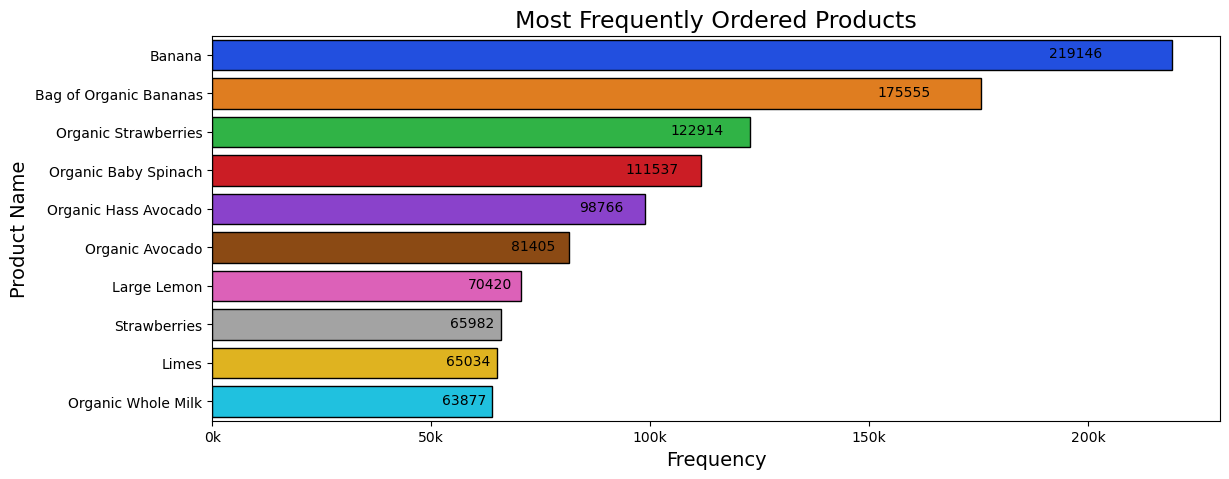

In [94]:
merged_product_order_product = order_products_prior.merge(product_df[['product_id','product_name']], on = 'product_id')
most_ordered_products = merged_product_order_product['product_name'].value_counts().nlargest(10).reset_index()

most_ordered_products.columns = ['product_name','count']
plt.figure(figsize=(13,5))
ax = sns.barplot(x='count',y='product_name', data = most_ordered_products,palette='bright', edgecolor='black')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x/1000):,.0f}k'))
for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    ax.text(
        width * 0.9,
        bar.get_y() + bar.get_height()/1.45,
        int(width),
        ha='center', va= 'bottom',
        fontsize=10
    )
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Product Name', fontsize=14)
plt.title('Most Frequently Ordered Products', fontsize=17)
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    <strong style="color: #b08d57;">Bananas dominate</strong> overall order volume, with <strong>Banana</strong> (<span style="color: #b08d57; font-weight: 700;">219,146</span>) and <strong>Bag of Organic Bananas</strong> (<span style="color: #b08d57; font-weight: 700;">175,555</span>) far outpacing every other product. <strong style="color: #b08d57;">Nine of the top ten items are fresh produce</strong>, and several categories appear twice in both organic and conventional form (Strawberries, Avocado), indicating a customer base with a <strong>strong preference for organic produce</strong> where the option exists. <strong>Organic Whole Milk</strong> is the only non-produce item to break into the top ten, suggesting dairy staples compete much further down the frequency curve than fresh fruits and vegetables.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 1 &middot; Question 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Which Departments and Aisles Generate the Highest Order Volume?
  </h2>
</div>

In [24]:
temp = order_products_prior.merge(product_df, on="product_id")
gc.collect()
temp = temp.merge(aisles_df, on="aisle_id")
gc.collect()
merged_order_products_department_aisles = temp.merge(department_df, on="department_id")
del temp
gc.collect()

0

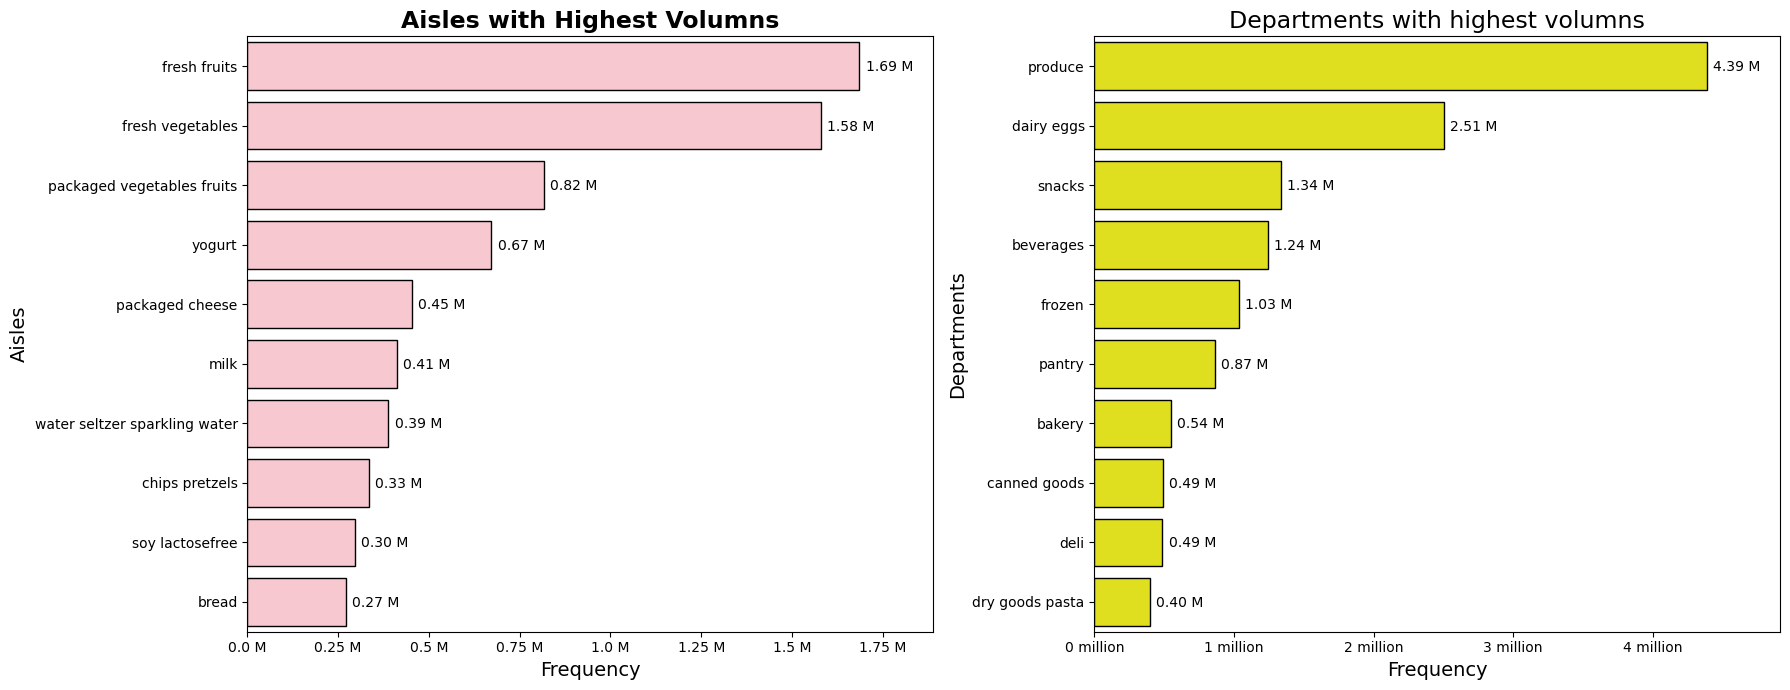

In [93]:
fig, ax = plt.subplots(1,2,figsize=(18,7))
highest_order_aisles = merged_order_products_department_aisles['aisle'].value_counts().nlargest(10).reset_index()
highest_order_aisles.columns = ['aisle' ,'frequency']

highest_volumn_departments = merged_order_products_department_aisles['department'].value_counts().nlargest(10).reset_index()
highest_volumn_departments.columns = ['department', 'frequency']

sns.barplot(x= 'frequency', y='aisle',ax = ax[0], data = highest_order_aisles, color='pink', edgecolor='black')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p : f'{x/1_000_000} M'))
for i, bar in enumerate(ax[0].patches):
    width = bar.get_width()
    ax[0].text(
        width + highest_order_aisles['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width/1_000_000):,.2f} M',
        ha='left', va='bottom',
        fontsize=10
    )
ax[0].set_xlim(0, highest_order_aisles['frequency'].max() * 1.12)
ax[0].set_title('Aisles with Highest Volumns', fontsize=17, fontweight='bold')
ax[0].set_xlabel('Frequency', fontsize=14)
ax[0].set_ylabel('Aisles', fontsize=14)


sns.barplot(x= 'frequency', y='department',ax = ax[1], data= highest_volumn_departments, color='yellow', edgecolor='black')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x/1_000_000):,.0f} million'))
for i, bar in enumerate(ax[1].patches):
    width = bar.get_width()
    ax[1].text(
        width + highest_volumn_departments['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width/1_000_000):,.2f} M',
        ha='left', va='bottom',
        fontsize=10
    )
ax[1].set_xlim(0,highest_volumn_departments['frequency'].max()*1.12)
ax[1].set_xlabel('Frequency', fontsize=14)
ax[1].set_ylabel('Departments', fontsize=14)
ax[1].set_title('Departments with highest volumns', fontsize=17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    <strong style="color: #b08d57;">Produce leads by a wide margin</strong> at the department level, generating <span style="color: #b08d57; font-weight: 700;">4.39M</span> orders, nearly <strong>double</strong> the second-place <strong>Dairy Eggs</strong> department (<span style="color: #b08d57; font-weight: 700;">2.51M</span>). At the aisle level, <strong>Fresh Fruits</strong> (<span style="color: #b08d57; font-weight: 700;">1.69M</span>) and <strong>Fresh Vegetables</strong> (<span style="color: #b08d57; font-weight: 700;">1.58M</span>) together account for the bulk of the Produce department's total, confirming that <strong style="color: #b08d57;">fresh, perishable staples drive the majority of order volume</strong> rather than packaged or shelf-stable goods. Notably, <strong>Snacks</strong> and <strong>Beverages</strong> outrank <strong>Frozen</strong> and <strong>Bakery</strong>, suggesting impulse and routine convenience items also carry meaningful weight in overall order composition.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 1 &middot; Question 3
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Is the Reorder Rate by Product, Aisle, and Department?
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Question 3 &middot; Product Level
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Most and Least Reordered Products
  </h2>
</div>

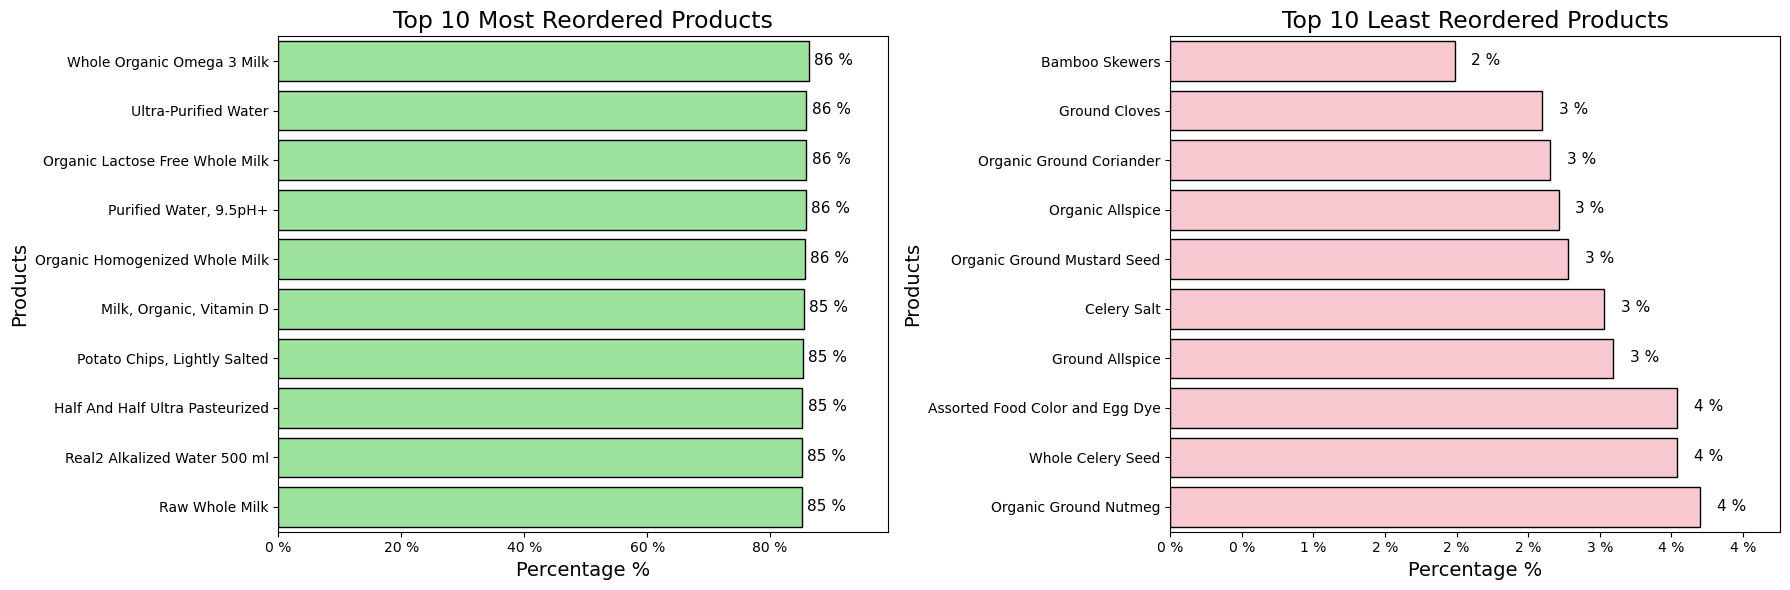

In [92]:
product_counts = merged_order_products_department_aisles.groupby('product_name')['reordered'].agg(['mean','count'])
product_counts = product_counts[product_counts['count'] >= 100] 

reordered_products_largest = product_counts['mean'].nlargest(10).reset_index()
reordered_products_largest.columns = ['product_name','frequency']

reordered_products_least = product_counts['mean'].sort_values().head(10).reset_index()
reordered_products_least.columns = ['product_name','frequency']

fig, ax = plt.subplots(1,2,figsize=(18,6))
sns.barplot(y='product_name',x='frequency', data = reordered_products_largest, ax=ax[0], color='lightgreen', edgecolor='black')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[0].patches):
    width = bar.get_width()
    ax[0].text(
        width + reordered_products_largest['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )
ax[0].set_xlim(0, reordered_products_largest['frequency'].max()*1.15)
ax[0].set_xlabel('Percentage %', fontsize = 14)
ax[0].set_ylabel('Products', fontsize = 14)
ax[0].set_title('Top 10 Most Reordered Products', fontsize = 17)

sns.barplot(y='product_name',x='frequency', data = reordered_products_least, ax=ax[1], color='pink', edgecolor='black')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[1].patches):
    width = bar.get_width()
    ax[1].text(
        width + reordered_products_least['frequency'].max() * 0.059,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'center', va='bottom',
        fontsize =11
    )
ax[1].set_xlim(0, reordered_products_least['frequency'].max()*1.15)
ax[1].set_xlabel('Percentage %', fontsize = 14)
ax[1].set_ylabel('Products', fontsize = 14)
ax[1].set_title('Top 10 Least Reordered Products', fontsize = 17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    With volume filtering applied to both ends, a clear pattern emerges: <strong style="color: #b08d57;">consumption frequency, not category or price, drives reorder behavior</strong>. The most reordered products (85–86%) are dominated by <strong>milk and water</strong> — items consumed daily and depleted quickly. The least reordered products (2–4%) are almost entirely <strong style="color: #b08d57;">spices, seasonings, and specialty baking items</strong> — Bamboo Skewers, Ground Cloves, Allspice, Nutmeg — goods bought once and used sparingly over months or years. This mirrors the aisle-level finding from earlier (Spices & Seasonings at the bottom, Milk at the top), confirming the same behavioral driver holds true down to the individual product level: <strong>the faster a product is consumed, the more often it gets reordered</strong>, regardless of what category or department it belongs to.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Question 3 &middot; Aisle Level
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Most and Least Reordered Aisles
  </h2>
</div>

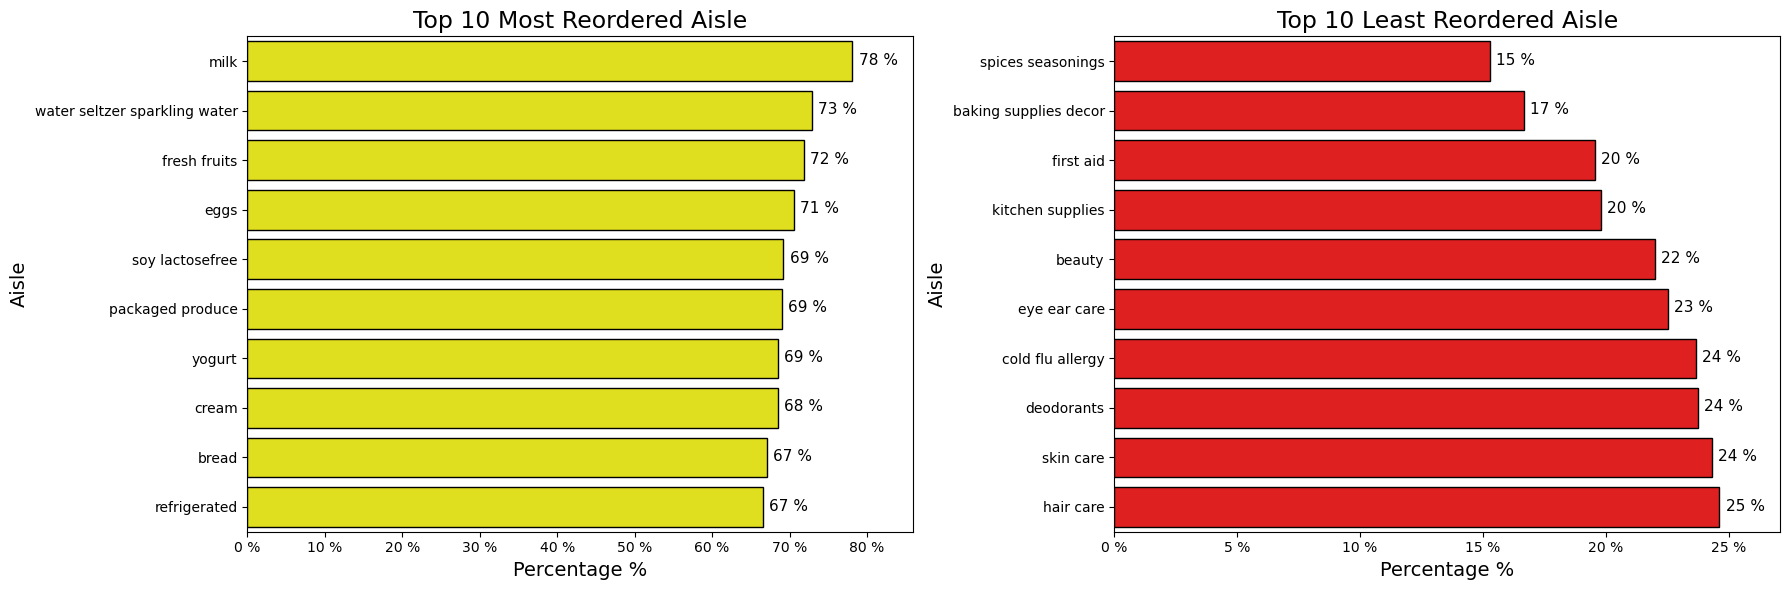

In [83]:
reordered_aisle_largest = merged_order_products_department_aisles.groupby('aisle')['reordered'].mean().nlargest(10).reset_index()
reordered_aisle_largest.columns = ['aisle','frequency']

reordered_aisle_least = merged_order_products_department_aisles.groupby('aisle')['reordered'].mean().sort_values().head(10).reset_index()
reordered_aisle_least.columns = ['aisle','frequency']

fig, ax = plt.subplots(1,2,figsize=(18,6))
sns.barplot(y='aisle',x='frequency', data = reordered_aisle_largest, ax=ax[0], color='yellow', edgecolor='black')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[0].patches):
    width = bar.get_width()
    ax[0].text(
        width + reordered_aisle_largest['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )
ax[0].set_xlim(0, reordered_aisle_largest['frequency'].max()*1.1)
ax[0].set_xlabel('Percentage %', fontsize = 14)
ax[0].set_ylabel('Aisle', fontsize = 14)
ax[0].set_title('Top 10 Most Reordered Aisle', fontsize = 17)
sns.barplot(y='aisle',x='frequency', data = reordered_aisle_least, ax=ax[1], color='red', edgecolor='black')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[1].patches):
    width = bar.get_width()
    ax[1].text(
        width + reordered_aisle_least['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )
ax[1].set_xlim(0, reordered_aisle_least['frequency'].max()*1.1)
ax[1].set_xlabel('Percentage %', fontsize = 14)
ax[1].set_ylabel('Aisle', fontsize = 14)
ax[1].set_title('Top 10 Least Reordered Aisle', fontsize = 17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    <strong style="color: #b08d57;">Perishable, everyday staples dominate reorder behavior</strong> at the aisle level. <strong>Milk</strong> leads with a <span style="color: #b08d57; font-weight: 700;">78%</span> reorder rate, followed by <strong>Water/Seltzer/Sparkling Water</strong> (<span style="color: #b08d57; font-weight: 700;">73%</span>), <strong>Fresh Fruits</strong> (<span style="color: #b08d57; font-weight: 700;">72%</span>), and <strong>Eggs</strong> (<span style="color: #b08d57; font-weight: 700;">71%</span>) — all short-shelf-life items customers must replenish frequently. On the opposite end, <strong>non-food and occasional-use aisles</strong> show far lower reorder rates: <strong>Spices &amp; Seasonings</strong> sits at just <span style="color: #b08d57; font-weight: 700;">15%</span>, alongside <strong>Baking Supplies</strong> (<span style="color: #b08d57; font-weight: 700;">17%</span>) and <strong>First Aid</strong> (<span style="color: #b08d57; font-weight: 700;">20%</span>). The pattern is clear: <strong style="color: #b08d57;">purchase frequency correlates strongly with product perishability and consumption pace</strong> — staples get restocked weekly, while pantry, health, and beauty items are bought once and last much longer.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Question 3 &middot; Department Level
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Most and Least Reordered Departments
  </h2>
</div>

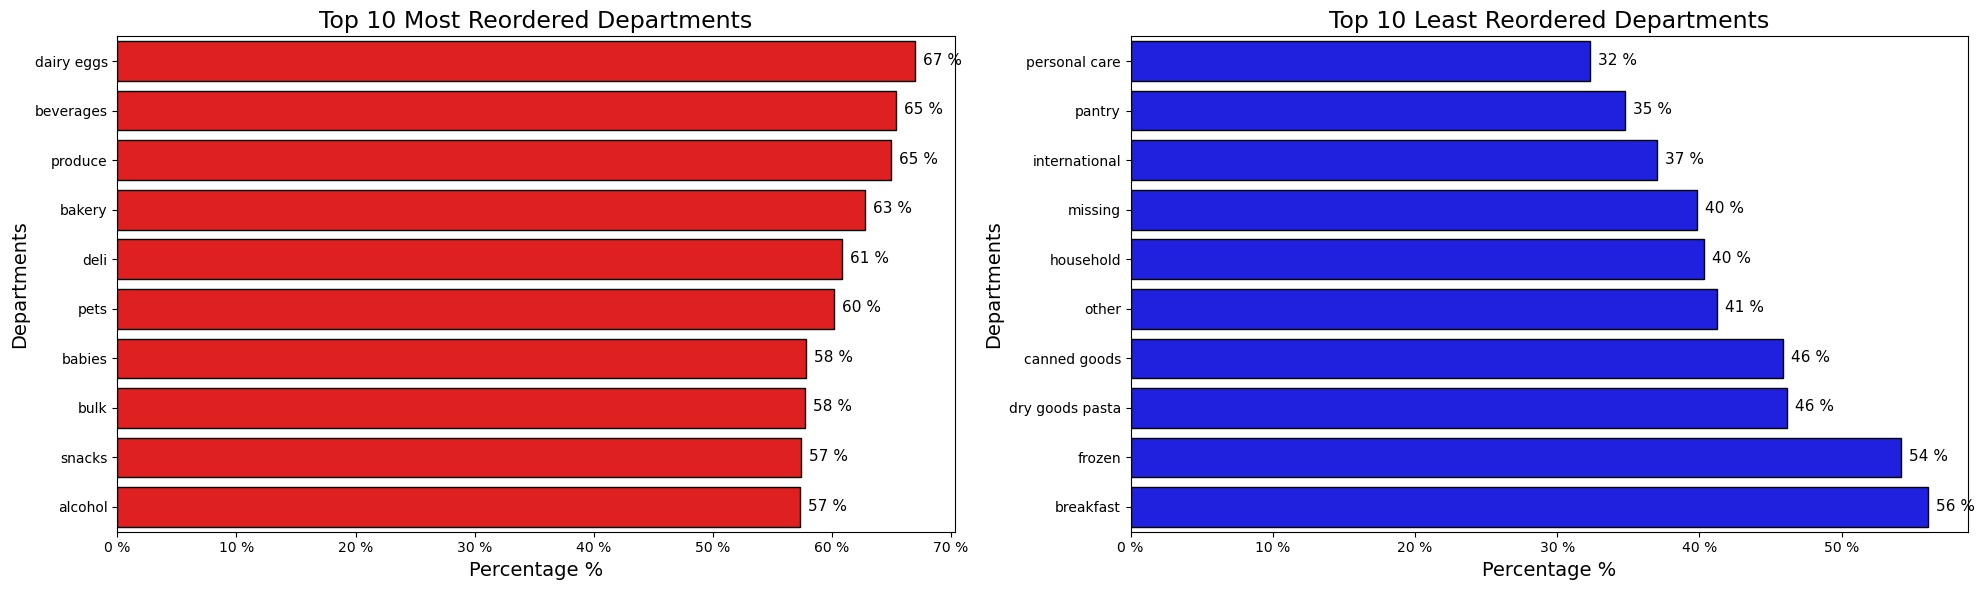

In [81]:
reordered_department_largest = merged_order_products_department_aisles.groupby('department')['reordered'].mean().nlargest(10).reset_index()
reordered_department_largest.columns = ['department','frequency']

reordered_department_least = merged_order_products_department_aisles.groupby('department')['reordered'].mean().sort_values().head(10).reset_index()
reordered_department_least.columns = ['department','frequency']

fig, ax = plt.subplots(1,2,figsize=(20,6))
sns.barplot(y='department',x='frequency', data = reordered_department_largest, ax=ax[0], color='red', edgecolor='black')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[0].patches):
    width = bar.get_width()
    ax[0].text(
        width + reordered_department_largest['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )

ax[0].set_xlabel('Percentage %', fontsize = 14)
ax[0].set_ylabel('Departments', fontsize = 14)
ax[0].set_title('Top 10 Most Reordered Departments', fontsize = 17
               
               )
sns.barplot(y='department',x='frequency', data = reordered_department_least, ax=ax[1], color='blue', edgecolor='black')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax[1].patches):
    width = bar.get_width()
    ax[1].text(
        width + reordered_department_least['frequency'].max()*0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )    
ax[1].set_xlabel('Percentage %', fontsize = 14)
ax[1].set_ylabel('Departments', fontsize = 14)
ax[1].set_title('Top 10 Least Reordered Departments', fontsize = 17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    At the department level, reorder rates are <strong style="color: #b08d57;">far more compressed</strong> than at the aisle level — the top department (<strong>Dairy Eggs</strong> at <span style="color: #b08d57; font-weight: 700;">67%</span>) and the bottom (<strong>Personal Care</strong> at <span style="color: #b08d57; font-weight: 700;">32%</span>) span a narrower range than individual aisles did, since departments blend fast-repeat and slow-repeat aisles together. <strong>Dairy Eggs, Beverages, and Produce</strong> lead, consistent with the perishable-staples pattern seen at the aisle level. On the low end, <strong>Personal Care, Pantry, and International</strong> foods show the weakest reorder behavior, reflecting <strong style="color: #b08d57;">longer product lifespans and more exploratory, one-off purchasing</strong> rather than routine restocking. Notably, <strong>Frozen</strong> (<span style="color: #b08d57; font-weight: 700;">54%</span>) and <strong>Breakfast</strong> (<span style="color: #b08d57; font-weight: 700;">56%</span>) rank higher here than their perishability alone might suggest, indicating these categories still function as regular household staples despite longer shelf life.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 1 &middot; Question 4
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Do High-Volume Departments Have Low Reorder Rates, and Vice Versa?
  </h2>
</div>

In [34]:
department_grouped_product_and_reordered = merged_order_products_department_aisles.groupby('department').agg({'product_name': 'count',
                                                                      'reordered' : 'mean'}).reset_index()

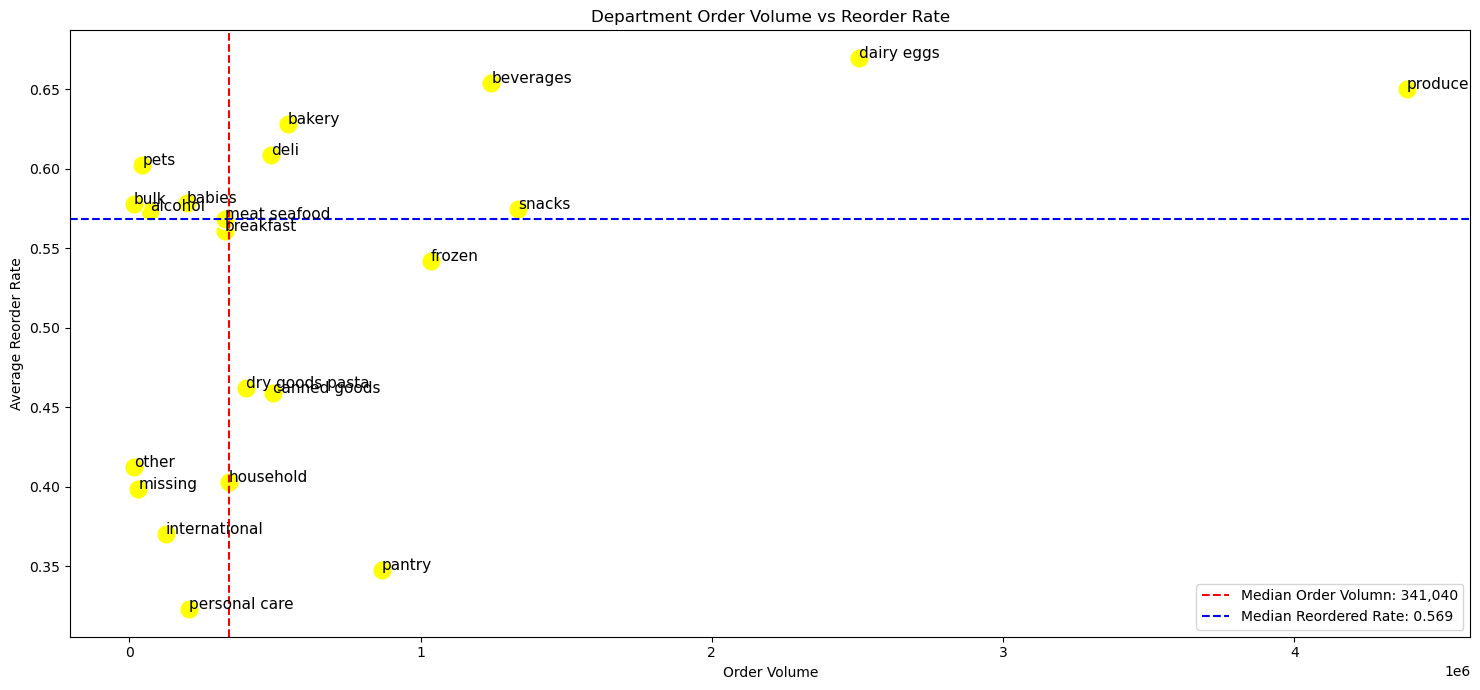

In [79]:
threshold_product = department_grouped_product_and_reordered['product_name'].median()
threshold_reordered = department_grouped_product_and_reordered['reordered'].median()
plt.figure(figsize=(15,7))
sns.scatterplot(data= department_grouped_product_and_reordered,
               x = 'product_name',
               y = 'reordered',color= 'yellow',
               s=200)
plt.axvline(threshold_product, color='red', linestyle='--', label= f'Median Order Volumn: {(threshold_product):,.0f}')
plt.axhline(threshold_reordered, color='blue', linestyle='--', label= f'Median Reordered Rate: {(threshold_reordered):,.3f}')

for i, row in department_grouped_product_and_reordered.iterrows():
    plt.text(
        row['product_name'],
        row['reordered'],
        row['department'],
        fontsize=11,
        ha='left'
    )
plt.xlabel("Order Volume")
plt.ylabel("Average Reorder Rate")
plt.title("Department Order Volume vs Reorder Rate")
plt.legend()
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    The data <strong style="color: #b08d57;">does not support the "novelty buy" hypothesis</strong> — high-volume departments do not show low reorder rates. Instead, <strong>Produce, Dairy Eggs, and Beverages</strong> sit in the upper-right quadrant, combining <strong>both the highest order volume and the highest reorder rates</strong>, confirming these are true high-frequency staples rather than one-time purchases. The genuine <strong style="color: #b08d57;">low-volume, high-reorder</strong> group (upper-left) includes niche but habitual categories like <strong>Pets, Bulk, Alcohol, and Babies</strong> — smaller customer bases who buy consistently once they start. Meanwhile, the <strong style="color: #b08d57;">low-volume, low-reorder</strong> departments (bottom-left) — <strong>Personal Care, Pantry, International, and Missing/Other</strong> — represent genuinely exploratory or infrequent purchases. Notably, there is <strong>no department combining high volume with low reorder rate</strong> (bottom-right is empty), suggesting that in this dataset, order volume and reorder rate are <strong style="color: #b08d57;">positively associated rather than inversely related</strong>.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Customer Purchase Behavior
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 2 &middot; Question 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Is the Distribution of Orders per Customer?
  </h2>
</div>

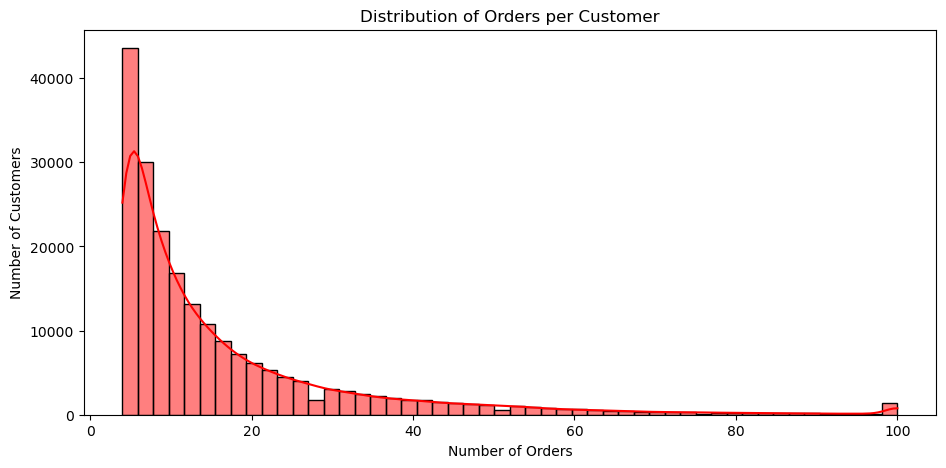

In [36]:
order_per_customers = order_df.groupby('user_id')['order_id'].count().reset_index(name ='total_order')
plt.figure(figsize=(11,5))
sns.histplot(data= order_per_customers, bins=50, x = 'total_order', kde= True, color='red')
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    Orders per customer follow a <strong style="color: #b08d57;">strongly right-skewed distribution</strong>, with the vast majority of customers placing relatively few orders. The largest single group has just around <span style="color: #b08d57; font-weight: 700;">4 to 6 orders</span>, and frequency drops off sharply from there, meaning <strong>most customers are light or occasional shoppers</strong> rather than habitual repeat buyers. A <strong style="color: #b08d57;">small tail of highly loyal customers</strong> persists out toward 60–100 orders, and a distinct spike appears right at the <span style="color: #b08d57; font-weight: 700;">100-order mark</span> — this is almost certainly a dataset artifact, where order history was capped at 100 per customer rather than a genuine behavioral pattern, and is worth noting explicitly in the report rather than over-interpreting as organic customer loyalty.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 2 &middot; Question 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Is the Average Days Since Prior Order?
  </h2>
</div>

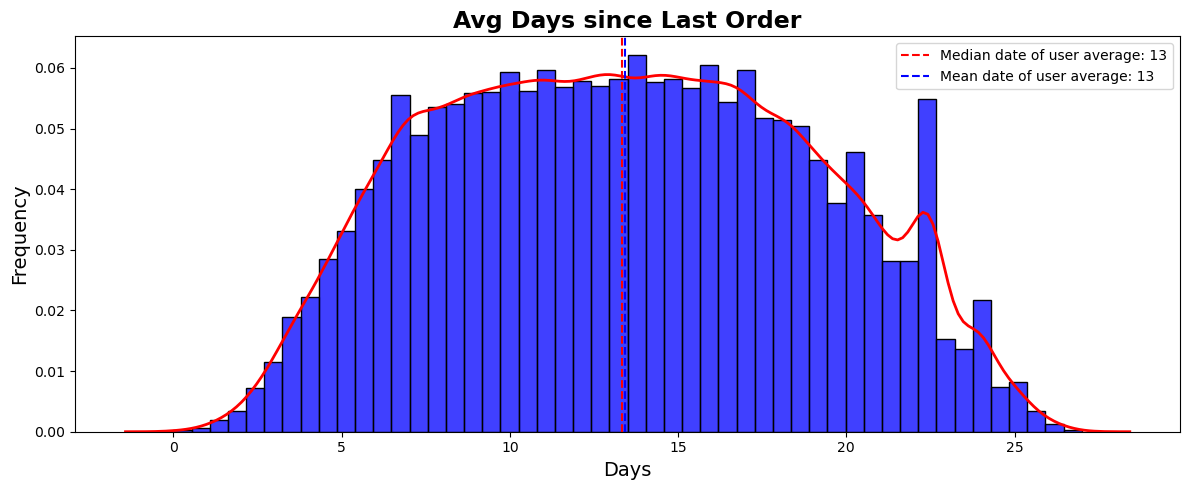

In [77]:
avg_day_since_last_order = order_df.groupby('user_id')['days_since_prior_order'].mean().reset_index(name='last_order')
median_line = avg_day_since_last_order['last_order'].median()
mean_line = avg_day_since_last_order['last_order'].mean()
plt.figure(figsize=(12,5))
sns.histplot(kde=False, bins=50, x='last_order', data= avg_day_since_last_order, color='blue', edgecolor='black', stat= 'density')
sns.kdeplot(data= avg_day_since_last_order, x='last_order',color='red', linewidth=2)
plt.axvline(median_line, color='red', linestyle='--', label=f'Median date of user average: {(median_line):,.0f}')
plt.axvline(mean_line, color='blue', linestyle='--', label=f'Mean date of user average: {(mean_line):,.0f}')
plt.legend()
plt.title('Avg Days since Last Order', fontsize=17, fontweight='bold')
plt.ylabel('Frequency', fontsize= 14)
plt.xlabel('Days', fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    The average days since prior order is centered around <strong style="color: #b08d57;">13 days</strong>, with mean and median nearly identical, indicating a <strong>fairly balanced, near-symmetric distribution</strong> rather than a heavily skewed one. Order frequency builds steadily from day 0, peaks in the <strong style="color: #b08d57;">7 to 17 day range</strong>, and then tapers off — suggesting most customers naturally settle into a <strong>roughly biweekly shopping rhythm</strong>. Two notable spikes stand out at <strong>7 days</strong> and especially <strong style="color: #b08d57;">around 22 to 23 days</strong>, likely reflecting distinct customer segments: weekly shoppers and monthly-ish shoppers, rather than a single uniform reorder cycle. The sharp drop-off after day 25 aligns with the dataset's cap on recorded intervals, so the true long-tail of infrequent shoppers is likely underrepresented here.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 2 &middot; Question 3
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Is the Average Basket Size?
  </h2>
</div>

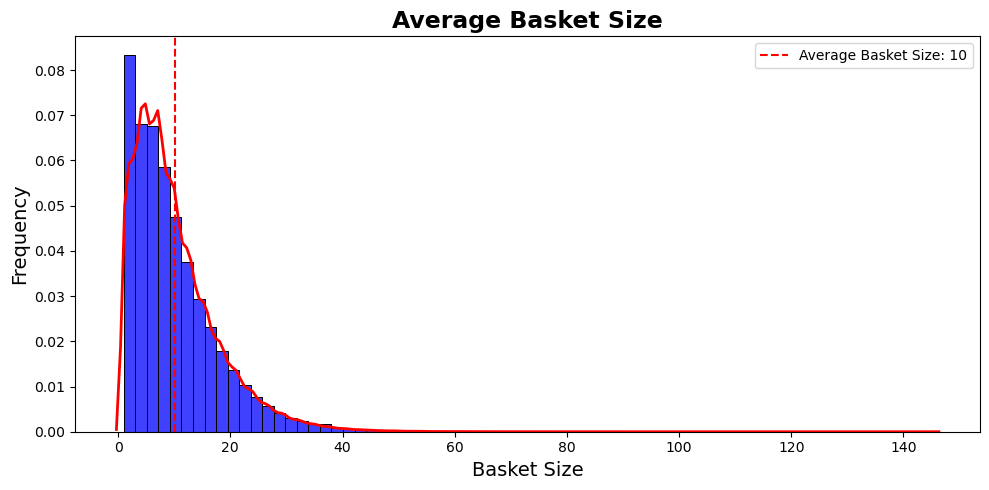

In [76]:
basket_sizes = order_products_prior.groupby('order_id')['product_id'].count().reset_index(name='size')
avg_basket_size = basket_sizes['size'].mean()
plt.figure(figsize=(10,5))
sns.histplot(data= basket_sizes, x='size',kde= False, bins=70, stat = 'density', color='blue')
plt.axvline(avg_basket_size, color='red', linestyle='--', label=f'Average Basket Size: {avg_basket_size:,.0f}')
sns.kdeplot(data= basket_sizes, x='size', color='red', linewidth=2)
plt.title('Average Basket Size', fontsize=17, fontweight='bold')
plt.xlabel('Basket Size', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    The average basket size sits at <strong style="color: #b08d57;">10 items</strong>, but the distribution is <strong>heavily right-skewed</strong>, meaning the mean overstates what a typical order actually looks like. The tallest bar falls near <span style="color: #b08d57; font-weight: 700;">1 to 5 items</span>, indicating that <strong>small, quick orders are by far the most common</strong> customer behavior rather than large bulk baskets. Frequency drops off sharply after roughly 20 items, with a long, thin tail extending out past 100 — a small number of unusually large orders are pulling the average upward. This suggests the <strong style="color: #b08d57;">median basket size is likely a more representative measure</strong> than the mean, and it would be worth reporting both side by side to avoid overstating typical order size.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 3
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Temporal and Seasonality Patterns
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 3 &middot; Question 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Which Day of Week Sees the Most Orders?
  </h2>
</div>

In [37]:
order_merge_prior = order_products_prior.merge(order_df,on='order_id')

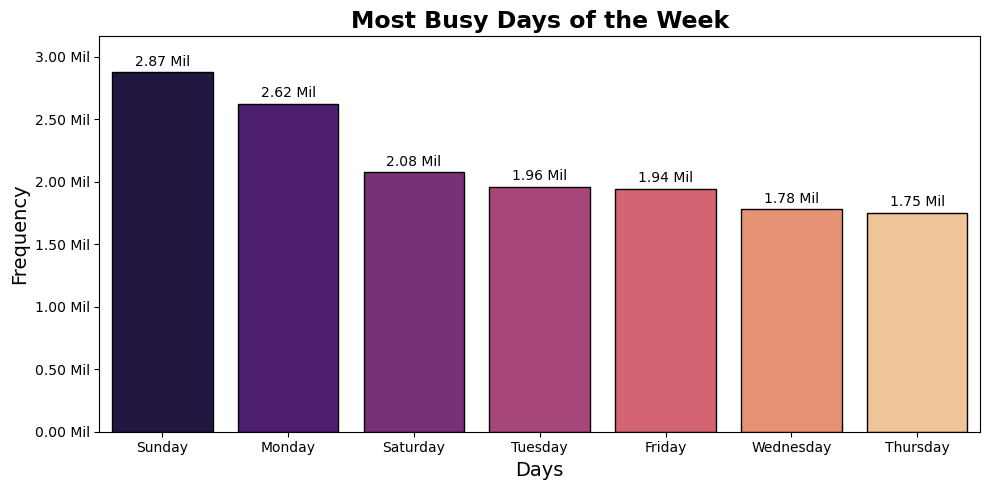

In [75]:
most_ordered_days = order_merge_prior.groupby('order_dow')['product_id'].count().sort_values(ascending=False).reset_index(name='count')
days_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}
most_ordered_days['order_dow'] = most_ordered_days['order_dow'].map(days_map)
plt.figure(figsize=(10,5))
ax = sns.barplot(x='order_dow',y='count',data = most_ordered_days, palette='magma', edgecolor='black')
ax.set_ylim(0, most_ordered_days['count'].max()*1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f'{(x/1_000_000):,.2f} Mil'))
for i , bar in enumerate(ax.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + most_ordered_days['count'].max() * 0.01,
        f'{(height/1_000_000):,.2f} Mil',
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_title('Most Busy Days of the Week', fontsize=17, fontweight='bold')
ax.set_xlabel('Days', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    <strong style="color: #b08d57;">Sunday and Monday are clearly the busiest ordering days</strong>, with <span style="color: #b08d57; font-weight: 700;">2.87M</span> and <span style="color: #b08d57; font-weight: 700;">2.62M</span> orders respectively, together accounting for a disproportionate share of weekly volume. This confirms that <strong>weekends do drive higher order activity</strong>, but the pattern is asymmetric rather than uniform across Saturday and Sunday — Saturday actually ranks third (<span style="color: #b08d57; font-weight: 700;">2.08M</span>), behind Monday. Order volume then flattens into a fairly consistent <strong>1.75M to 1.96M range</strong> across Tuesday through Thursday, with Wednesday and Thursday as the quietest days. The likely explanation is a <strong style="color: #b08d57;">weekly grocery-planning cycle</strong>: customers stock up heading into or right after the weekend, with demand steadily declining as the week progresses toward the next restock.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 3 &middot; Question 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Hour of Day Has Peak Ordering Activity?
  </h2>
</div>

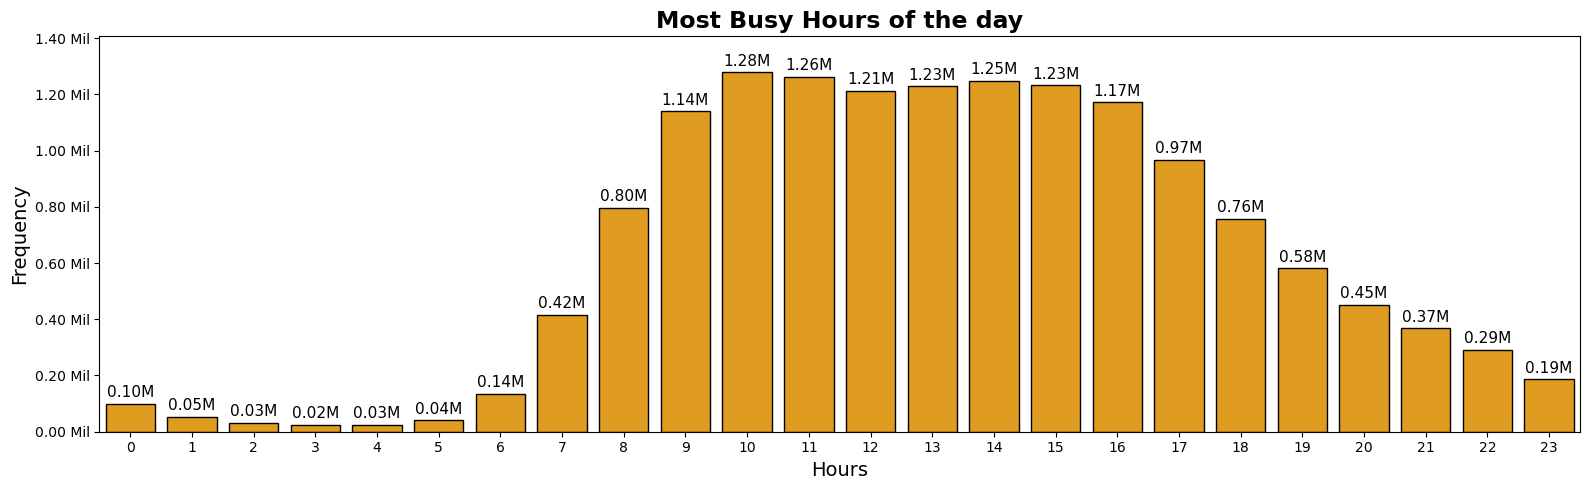

In [70]:
most_busy_days = order_merge_prior.groupby('order_hour_of_day')['product_id'].count().reset_index(name='count').sort_values(by='count',ascending=False)
plt.figure(figsize=(16,5))
ax = sns.barplot(data = most_busy_days, x = 'order_hour_of_day', y= 'count', color='orange', edgecolor='black')
ax.set_ylim(0, most_busy_days['count'].max()*1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x/1_000_000):,.2f} Mil'))
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + most_busy_days['count'].max() * 0.01,
        f'{(height/1_000_000):,.2f}M',
        ha='center', va='bottom',
        fontsize=11
    )
ax.set_title('Most Busy Hours of the day', fontsize=17, fontweight='bold')
ax.set_xlabel('Hours', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    Ordering activity follows a <strong style="color: #b08d57;">clear daytime pattern</strong>, staying near zero overnight (midnight to 5 AM) before ramping up sharply between <span style="color: #b08d57; font-weight: 700;">6 AM and 9 AM</span>. Volume then plateaus at its peak from <strong style="color: #b08d57;">10 AM through 4 PM</strong>, hovering consistently around <span style="color: #b08d57; font-weight: 700;">1.14M to 1.28M</span> orders per hour — this six-to-seven hour window is where the large majority of daily activity concentrates, rather than a single sharp peak hour. After 4 PM, volume declines steadily through the evening, dropping to under <span style="color: #b08d57; font-weight: 700;">0.2M</span> by 11 PM. This suggests customers are <strong>predominantly ordering during standard daytime and working hours</strong>, with minimal late-night or early-morning activity — a useful signal for planning fulfillment staffing or timing promotional pushes.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 3 &middot; Question 3
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Is There a Combined Relationship Between Day of Week and Hour of Day?
  </h2>
</div>

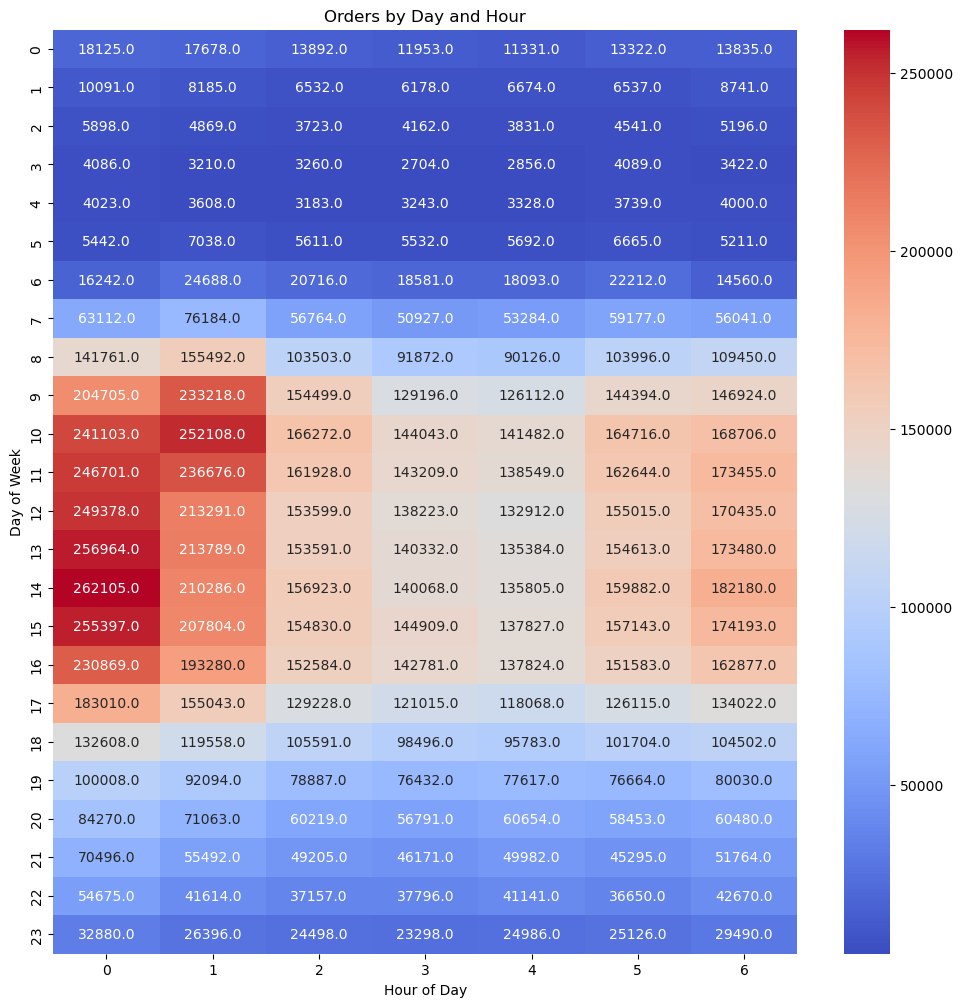

In [42]:
heatmap_data = order_merge_prior.groupby(['order_hour_of_day','order_dow'])['product_id'].count().unstack(fill_value=0)
plt.figure(figsize=(12,12))
sns.heatmap(
    heatmap_data,
    annot= True,
    fmt='.1f',
    cmap='coolwarm'
)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Orders by Day and Hour")
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    The heatmap confirms that <strong style="color: #b08d57;">day-of-week and hour-of-day effects compound rather than act independently</strong>. The single busiest window falls in the <strong>0–1 index range</strong> (the two highest-volume days) combined with the <strong style="color: #b08d57;">9 through 16 hour range</strong>, peaking above <span style="color: #b08d57; font-weight: 700;">260,000 orders</span> in that overlap — noticeably higher than what either the day-level or hour-level charts alone would suggest. Order volume stays low overnight <strong>across every day of the week</strong>, meaning the daytime dip-to-peak pattern is consistent regardless of which day it is, but the size of the daytime peak varies substantially depending on the day. This reinforces that <strong style="color: #b08d57;">promotional or staffing decisions should account for both dimensions together</strong>, not just the busiest day or busiest hour in isolation.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 4
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Reorder Behavior
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 4 &middot; Question 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    What Percentage of Items Are Reorders vs. First-Time Purchases?
  </h2>
</div>

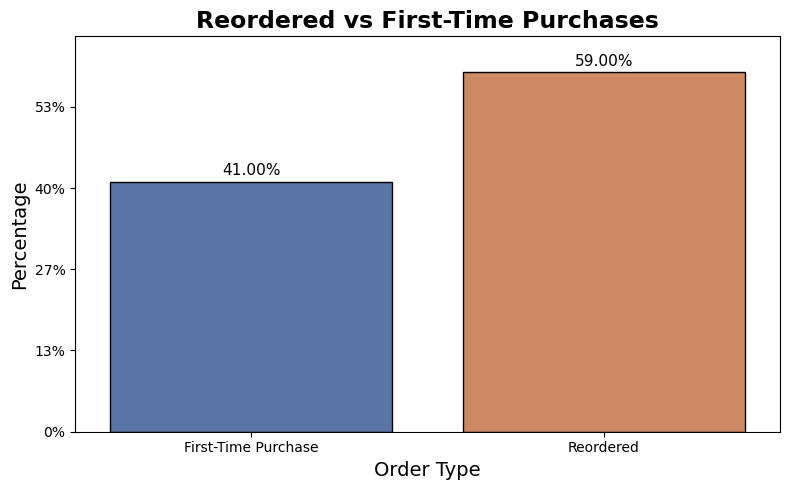

In [68]:
reorder_status_count = order_products_prior.groupby('reordered')['product_id'].count().reset_index(name='frequency')
plt.figure(figsize=(8,5))
ax = sns.barplot(data=reorder_status_count, x='reordered', y='frequency', palette='deep', edgecolor='black')
ax.set_ylim(0, reorder_status_count['frequency'].max()*1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x/reorder_status_count["frequency"].sum())*100:,.0f}%'))
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + reorder_status_count['frequency'].max() * 0.01,
        f'{(height/reorder_status_count["frequency"].sum())*100:,.2f}%',
        ha='center', va='bottom',
        fontsize=11
    )
ax.set_xticklabels(['First-Time Purchase', 'Reordered'])
ax.set_title('Reordered vs First-Time Purchases', fontsize=17, fontweight='bold')
ax.set_xlabel('Order Type', fontsize=14)
ax.set_ylabel('Percentage', fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    <strong style="color: #b08d57;">Reordered items make up the majority</strong> of all items purchased, accounting for <span style="color: #b08d57; font-weight: 700;">59%</span> of orders compared to <span style="color: #b08d57; font-weight: 700;">41%</span> for first-time purchases. This nearly 3-in-5 split indicates that <strong>repeat buying behavior dominates the platform</strong> rather than one-off exploratory purchases, reinforcing the broader pattern seen throughout this analysis: customers largely use the platform to <strong style="color: #b08d57;">restock familiar staples</strong> rather than to discover new products. This baseline figure is also a useful reference point against which product-, aisle-, and department-level reorder rates can be compared to identify which categories over- or under-index relative to the platform average.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 4 &middot; Question 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Which Products Have the Highest Reorder Rate?
  </h2>
</div>

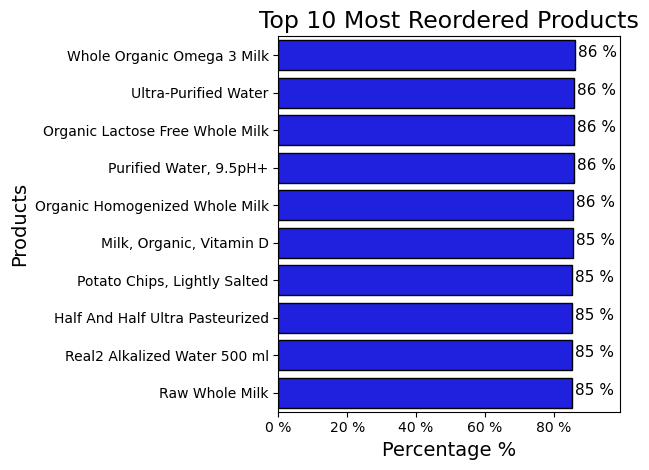

In [67]:
product_counts = merged_order_products_department_aisles.groupby('product_name')['reordered'].agg(['mean','count'])
product_counts = product_counts[product_counts['count'] >= 100]  # adjust threshold as needed
reordered_products_largest = product_counts['mean'].nlargest(10).reset_index()
reordered_products_largest.columns = ['product_name','frequency']
ax = sns.barplot(y='product_name',x='frequency', data = reordered_products_largest ,color='blue', edgecolor='black')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f} %'))
for i, bar in enumerate(ax.patches):
    
    width = bar.get_width()
    ax.text(
        width + reordered_products_largest['frequency'].max() * 0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width * 100):,.0f} %',
        ha = 'left', va='bottom',
        fontsize =11
    )
ax.set_xlim(0, reordered_products_largest['frequency'].max()*1.15)
ax.set_xlabel('Percentage %', fontsize = 14)
ax.set_ylabel('Products', fontsize = 14)
ax.set_title('Top 10 Most Reordered Products', fontsize = 17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    With the low-volume filter applied, the ranking now reflects <strong style="color: #b08d57;">genuine repeat-buy behavior</strong> rather than statistical noise from rarely-ordered items. The top products cluster tightly between <span style="color: #b08d57; font-weight: 700;">85% and 86%</span> reorder rate, and the list is dominated by <strong>milk variants and purified/alkalized water</strong> — categories defined by short shelf life and non-negotiable, routine consumption. This is notably higher than the platform-wide reorder rate of 59% established earlier, confirming that these specific staples sit at the <strong style="color: #b08d57;">extreme high end of purchase habituality</strong>. The one outlier, <strong>Potato Chips, Lightly Salted</strong>, stands out as the only non-dairy, non-water item in the list — worth a closer look, as it may indicate a smaller but exceptionally loyal customer segment rather than broad category-wide behavior.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 4 &middot; Question 3
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Is There a Relationship Between add_to_cart_order and Likelihood of Being a Reorder? (Do People Add Their "Regulars" First?)
  </h2>
</div>

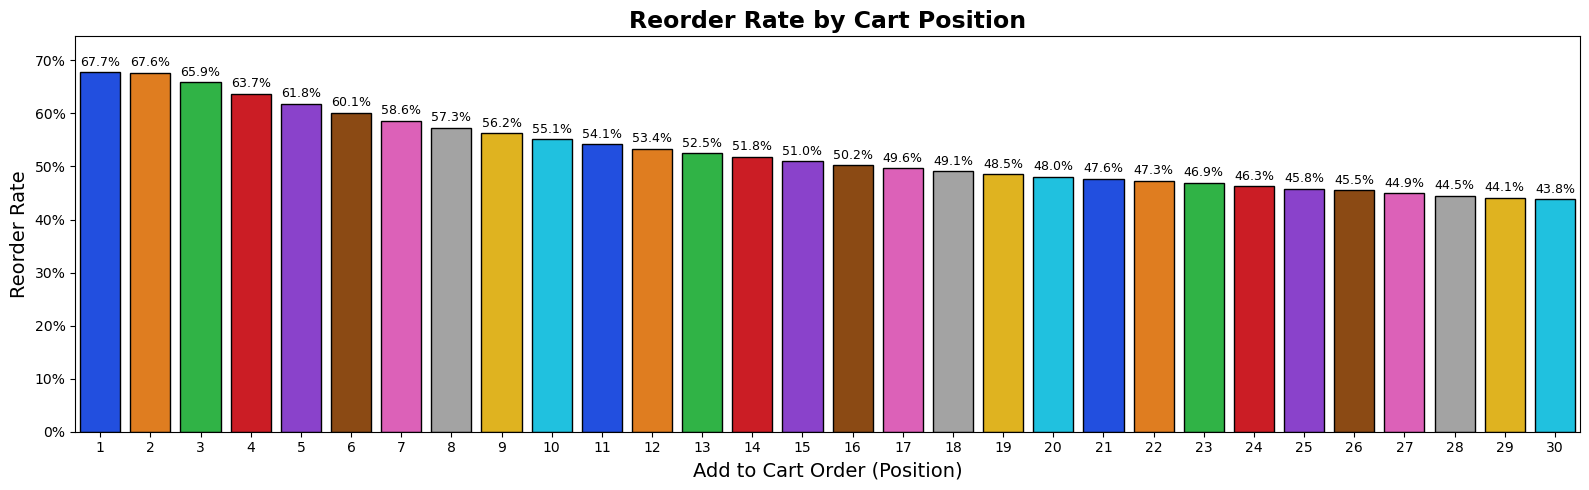

In [66]:
add_to_cart_reorder_rate = order_products_prior.groupby('add_to_cart_order')['reordered'].mean().reset_index(name='reorder_rate')
add_to_cart_reorder_rate = add_to_cart_reorder_rate[add_to_cart_reorder_rate['add_to_cart_order'] <= 30]

plt.figure(figsize=(16,5))
ax = sns.barplot(data=add_to_cart_reorder_rate, x='add_to_cart_order', y='reorder_rate', palette='bright', edgecolor='black')
ax.set_ylim(0, add_to_cart_reorder_rate['reorder_rate'].max()*1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x*100):,.0f}%'))
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + add_to_cart_reorder_rate['reorder_rate'].max() * 0.01,
        f'{(height*100):,.1f}%',
        ha='center', va='bottom',
        fontsize=9
    )
ax.set_title('Reorder Rate by Cart Position', fontsize=17, fontweight='bold')
ax.set_xlabel('Add to Cart Order (Position)', fontsize=14)
ax.set_ylabel('Reorder Rate', fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    Reorder rate <strong style="color: #b08d57;">declines steadily and consistently</strong> as cart position increases, confirming the hypothesis that customers <strong>add their routine, familiar items first</strong>. The first item added to cart has the highest reorder likelihood at <span style="color: #b08d57; font-weight: 700;">67.7%</span>, and this decays almost monotonically down to <span style="color: #b08d57; font-weight: 700;">43.8%</span> by the 30th position — a drop of nearly <strong>24 percentage points</strong> across the range. This pattern suggests customers <strong style="color: #b08d57;">shop habitually before shopping exploratively</strong>: staples and regulars get added on autopilot early in the trip, while items added later in the cart are more likely to be new, seasonal, or impulse purchases. This has a practical implication for product placement or recommendation timing — early-cart real estate is dominated by habit, not discovery.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 5
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Department and Aisle Level Segmentation
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 5 &middot; Question 1
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Rank Departments and Aisles by Total Items Sold
  </h2>
</div>

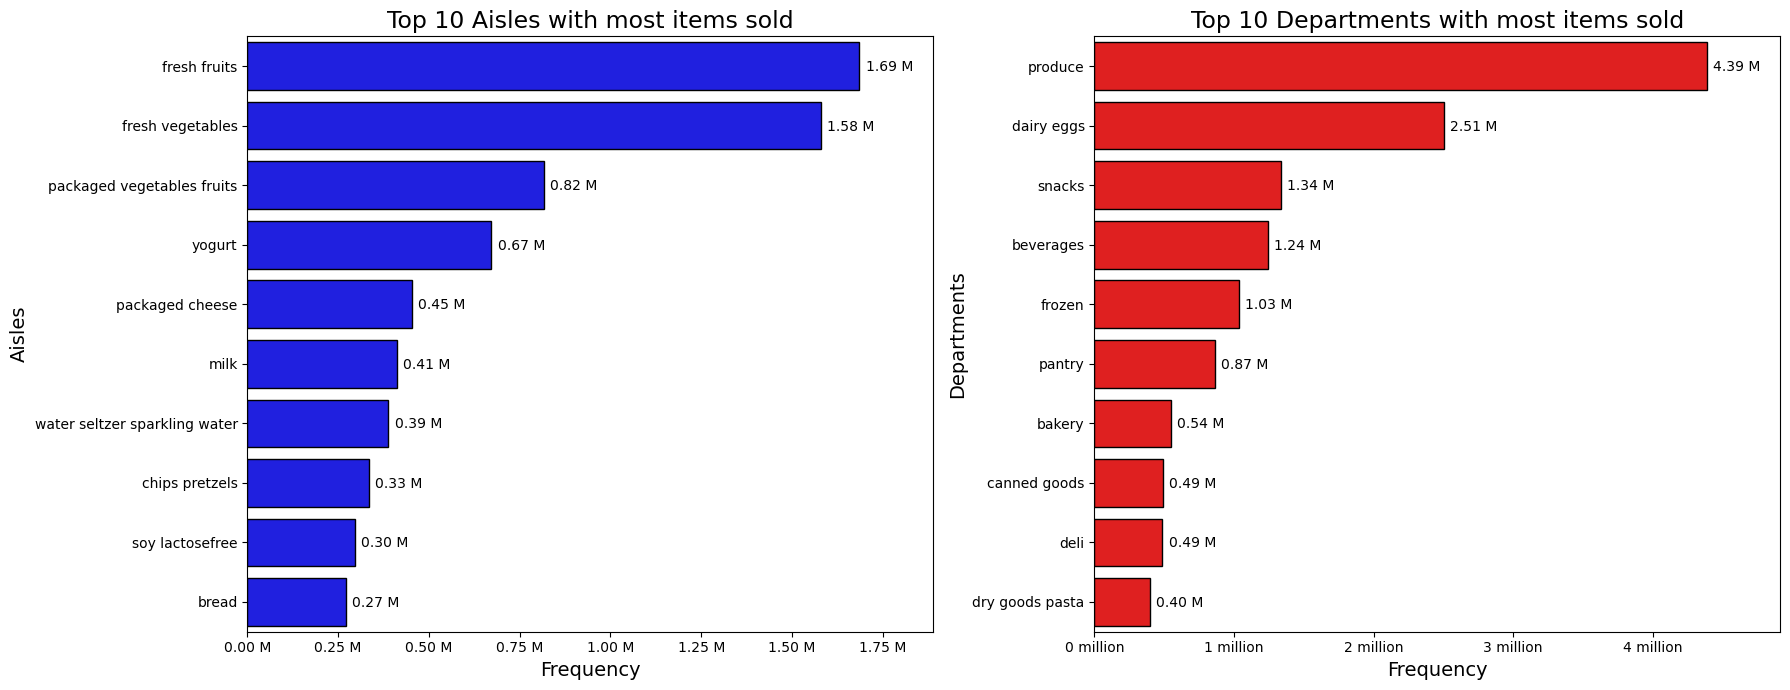

In [61]:
fig, ax = plt.subplots(1,2,figsize=(18,7))
highest_order_aisles = merged_order_products_department_aisles['aisle'].value_counts().nlargest(10).reset_index()
highest_order_aisles.columns = ['aisle' ,'frequency']

highest_volumn_departments = merged_order_products_department_aisles['department'].value_counts().nlargest(10).reset_index()
highest_volumn_departments.columns = ['department', 'frequency']

sns.barplot(x= 'frequency', y='aisle',ax = ax[0], data = highest_order_aisles, color='blue', edgecolor='black')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p : f'{(x/1_000_000):,.2f} M'))
for i, bar in enumerate(ax[0].patches):
    width = bar.get_width()
    ax[0].text(
        width + highest_order_aisles['frequency'].max() * 0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width/1_000_000):,.2f} M',
        ha='left', va='bottom',
        fontsize=10
    )
ax[0].set_xlim(0, highest_order_aisles['frequency'].max() * 1.12)
ax[0].set_title('Top 10 Aisles with most items sold', fontsize=17)
ax[0].set_xlabel('Frequency', fontsize=14)
ax[0].set_ylabel('Aisles', fontsize=14)


sns.barplot(x= 'frequency', y='department',ax = ax[1], data= highest_volumn_departments, color='red', edgecolor='black')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{(x/1_000_000):,.0f} million'))
for i, bar in enumerate(ax[1].patches):
    width = bar.get_width()
    ax[1].text(
        width + highest_volumn_departments['frequency'].max() * 0.01,
        bar.get_y() + bar.get_height()/1.5,
        f'{(width/1_000_000):,.2f} M',
        ha='left', va='bottom',
        fontsize=10
    )
ax[1].set_xlim(0,highest_volumn_departments['frequency'].max()*1.12)
ax[1].set_xlabel('Frequency', fontsize=14)
ax[1].set_ylabel('Departments', fontsize=14)
ax[1].set_title('Top 10 Departments with most items sold', fontsize=17)
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    Ranked purely by total items sold, the picture is <strong style="color: #b08d57;">nearly identical to the earlier order-volume ranking</strong>, reinforcing that Produce and Dairy Eggs are not just ordered frequently but also contribute the highest raw item counts. <strong>Produce</strong> leads decisively at <span style="color: #b08d57; font-weight: 700;">4.39M</span> items, more than <strong>1.7 times</strong> the second-place <strong>Dairy Eggs</strong> department (<span style="color: #b08d57; font-weight: 700;">2.51M</span>). At the aisle level, <strong>Fresh Fruits</strong> (<span style="color: #b08d57; font-weight: 700;">1.69M</span>) and <strong>Fresh Vegetables</strong> (<span style="color: #b08d57; font-weight: 700;">1.58M</span>) alone account for a substantial share of the entire Produce department's total, confirming these two aisles as the <strong style="color: #b08d57;">single largest volume drivers in the business</strong>. The consistency between this item-count view and the earlier order-count view suggests these top categories aren't just present in many orders — they also tend to appear in larger quantities per order.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Section 5 &middot; Question 2
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Identify the Top 5 Products per Department
  </h2>
</div>

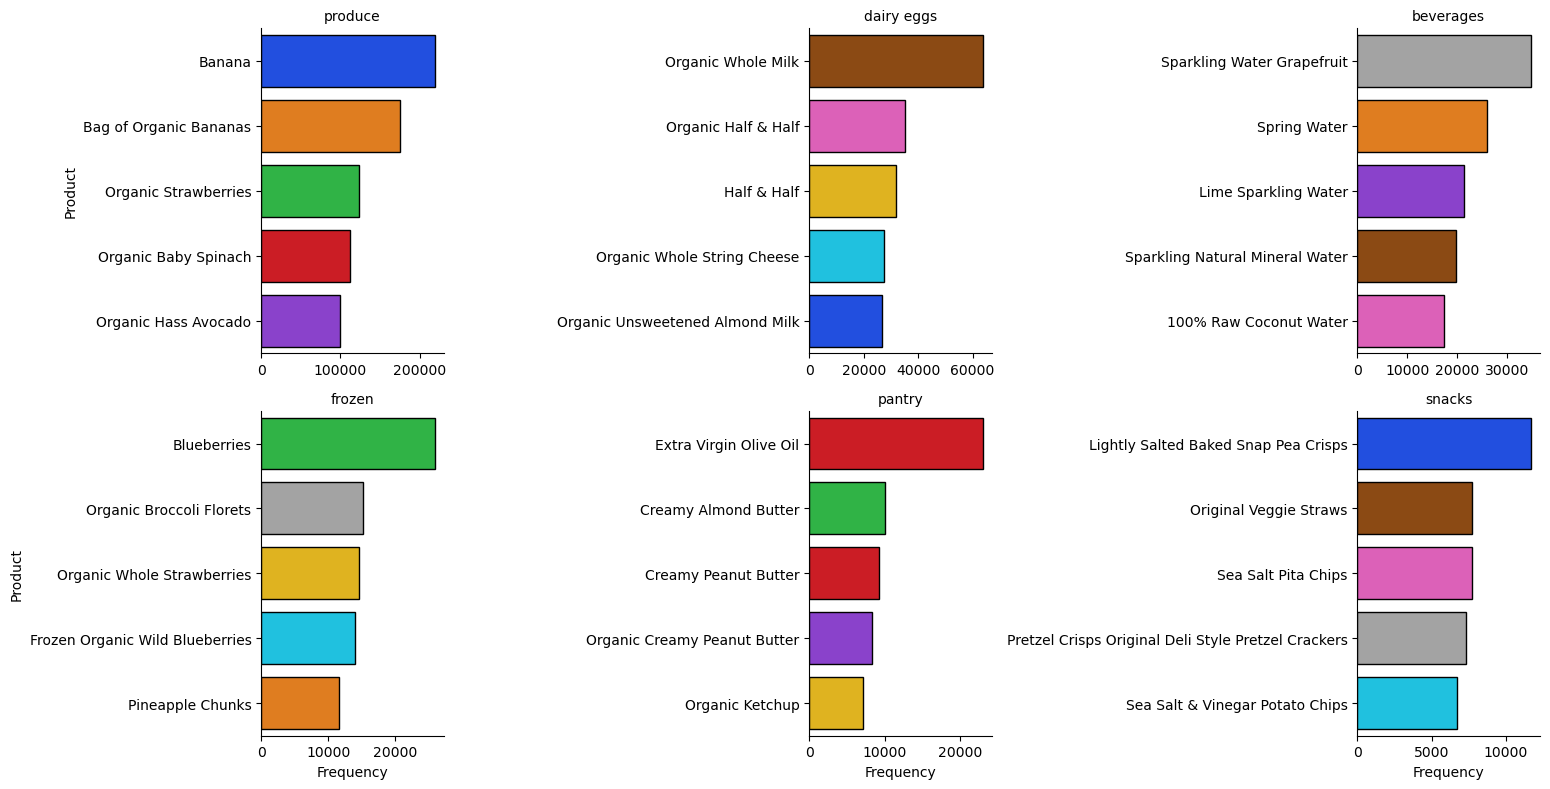

In [95]:
a = merged_order_products_department_aisles.groupby(['department','product_name'])['product_id'].count().reset_index(name='count').sort_values(by='count', ascending=False)
top5_per_department = a.groupby('department').head(5)
top_departments = merged_order_products_department_aisles.groupby('department')['product_id'].count().sort_values(ascending=False).head(6).index
top5_filtered = top5_per_department[top5_per_department['department'].isin(top_departments)]
ax = sns.catplot(
    data=top5_filtered,
    x='count', y='product_name',
    col='department', col_wrap=3,
    kind='bar', palette='bright', edgecolor='black',
    height=4, aspect=1.3,
    sharex=False, sharey=False
)
ax.set_titles('{col_name}')
ax.set_axis_labels('Frequency', 'Product')
plt.tight_layout()
plt.show()

<div style="background-color: #f3f0ea; border-left: 3px solid #b08d57; border-radius: 4px; padding: 14px 20px; margin: 16px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; font-weight: 700;">
    Finding
  </p>
  <p style="margin: 0; color: #1f2937; font-family: 'Georgia', serif; font-size: 15px; line-height: 1.7;">
    Breaking down the top departments by product reveals <strong style="color: #b08d57;">a single dominant item in most categories</strong> rather than an even spread across the top 5. In <strong>Produce</strong>, <strong>Banana</strong> alone accounts for roughly <span style="color: #b08d57; font-weight: 700;">200,000+</span> orders, well ahead of its closest competitor. Similarly, <strong>Organic Whole Milk</strong> leads Dairy Eggs by a wide margin, and <strong>Extra Virgin Olive Oil</strong> dominates Pantry at nearly triple its next-closest rival. A recurring theme across <strong style="color: #b08d57;">Beverages, Frozen, and Pantry</strong> is a strong lean toward health-conscious, minimally processed products — sparkling and mineral waters over sugary drinks, organic and creamy nut butters over conventional spreads. Meanwhile <strong>Snacks</strong> shows the most even distribution among its top 5 products, suggesting customers are more exploratory or brand-agnostic in that category compared to staples like milk or olive oil, where one product clearly wins customer loyalty.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 26px 32px; margin: 22px 0; border-left: 5px solid #b08d57; box-shadow: 0 3px 10px rgba(0,0,0,0.22);">
  <p style="margin: 0 0 10px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">
    Summary
  </p>
  <div style="height: 1px; background: linear-gradient(90deg, #b08d57 0%, transparent 70%); width: 100%; margin-bottom: 10px;"></div>
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 27px; letter-spacing: 0.2px;">
    Conclusion
  </h2>
</div>

<div style="background-color: #1f2937; border-radius: 10px; padding: 30px 36px; margin: 24px 0;">
  <p style="margin: 0 0 6px 0; color: #b08d57; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 3.5px; text-transform: uppercase;">Final Report</p>
  <h1 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', 'Cambria', serif; font-weight: 700; font-size: 30px;">Instacart Market Basket Analysis</h1>
  <p style="margin: 10px 0 0 0; color: #c9c4b8; font-family: 'Georgia', serif; font-size: 14px; font-style: italic;">A behavioral and operational analysis of customer ordering patterns</p>
</div>

<div style="border: 1px solid #b08d57; border-radius: 6px; padding: 18px 24px; margin: 16px 0; background-color: #fdfbf7;">
  <p style="margin: 0 0 8px 0; color: #8a6a3a; font-family: 'Georgia', serif; font-size: 12px; letter-spacing: 2px; text-transform: uppercase; font-weight: 700;">Executive Summary</p>
  <p style="margin: 0; color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
    This analysis examined ordering behavior across roughly 32 million order-item records to understand what customers buy, how often they return, and when they shop. The central finding is that <strong>customer behavior is overwhelmingly habitual rather than exploratory</strong>: 59% of all items purchased are reorders, driven primarily by perishable staples such as milk, produce, and water. Ordering activity concentrates in a predictable daytime window (9 AM–4 PM) with Sunday and Monday as peak days, and reorder likelihood decays steadily the later a product is added to cart, suggesting customers shop routine items first and discretionary items second. These patterns point toward clear opportunities in staffing, retention targeting, and category-specific promotion strategy, detailed in the recommendations section below.
  </p>
</div>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">1. Product and Category Performance</h2>
</div>
<table style="width: 100%; border-collapse: collapse; font-family: 'Georgia', serif; font-size: 14px; margin-bottom: 12px;">
  <tr style="background-color: #f3f0ea;">
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Metric</th>
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Result</th>
  </tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Top product by volume</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Banana — 219,146 orders</td></tr>
  <tr style="background-color: #faf8f4;"><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Top department</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Produce — 4.39M items</td></tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Highest product reorder rate</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Whole Organic Omega 3 Milk — 86%</td></tr>
  <tr style="background-color: #faf8f4;"><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Lowest product reorder rate</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Bamboo Skewers — 2%</td></tr>
</table>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  Reorder rate is driven almost entirely by <strong>consumption speed, not price or category prestige</strong> — dairy and water dominate the top of every ranking (product, aisle, and department level), while spices, seasonings, and specialty items dominate the bottom. High order volume and high reorder rate move together rather than trading off: no department combines strong volume with weak repeat behavior.
</p>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">2. Customer Purchase Behavior</h2>
</div>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  Most customers are <strong>light, infrequent shoppers</strong> — the largest single group places just 4–6 total orders, with frequency dropping off sharply beyond that. A smaller loyal segment persists out toward 100 orders (the dataset's apparent cap). The typical customer reorders roughly every <strong>13 days</strong>, with two visible behavioral clusters around 7 days (weekly shoppers) and 22–23 days (near-monthly shoppers). Average basket size is <strong>10 items</strong>, though the distribution is right-skewed, with most orders containing 1–5 items and a long tail of large bulk orders pulling the mean upward — the median is a more representative figure for typical basket size.
</p>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">3. Temporal and Seasonality Patterns</h2>
</div>
<table style="width: 100%; border-collapse: collapse; font-family: 'Georgia', serif; font-size: 14px; margin-bottom: 12px;">
  <tr style="background-color: #f3f0ea;">
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Dimension</th>
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Peak</th>
  </tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Day of week</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Sunday (2.87M), Monday (2.62M)</td></tr>
  <tr style="background-color: #faf8f4;"><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Hour of day</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">10 AM – 4 PM plateau</td></tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Combined peak</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Sun/Mon, 9 AM–4 PM window</td></tr>
</table>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  Day and hour effects <strong>compound rather than act independently</strong> — the combined Sunday/Monday daytime window sees substantially higher volume than either dimension alone would predict, with near-zero activity overnight regardless of the day.
</p>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">4. Reorder Behavior</h2>
</div>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  <strong>59% of all items purchased are reorders</strong> versus 41% first-time purchases, establishing repeat buying as the dominant behavior on the platform. Reorder likelihood is also strongly tied to <strong>cart position</strong> — items added first have a 67.7% reorder rate, declining nearly monotonically to 43.8% by the 30th item added. This indicates customers build their cart habitually before shopping exploratively, adding routine staples first and discretionary items later.
</p>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">5. Department and Aisle Segmentation</h2>
</div>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  Top-5-per-department analysis reveals that most categories are led by a <strong>single dominant product</strong> rather than an even spread — Banana in Produce, Organic Whole Milk in Dairy Eggs, and Extra Virgin Olive Oil in Pantry each outsell their nearest in-category competitor by a wide margin. Snacks is the one notable exception, showing a more even distribution across its top 5 items, suggesting more brand-agnostic, exploratory behavior in that category specifically.
</p>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">Recommendations</h2>
</div>
<table style="width: 100%; border-collapse: collapse; font-family: 'Georgia', serif; font-size: 14px; margin-bottom: 12px;">
  <tr style="background-color: #f3f0ea;">
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Area</th>
    <th style="text-align: left; padding: 8px 12px; border: 1px solid #d8cbb0; color: #1f2937;">Recommendation</th>
  </tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0; font-weight: 700; color: #8a6a3a;">Staffing / Fulfillment</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Scale warehouse and delivery capacity to the Sunday–Monday, 9 AM–4 PM demand window rather than spreading resources evenly across the week.</td></tr>
  <tr style="background-color: #faf8f4;"><td style="padding: 8px 12px; border: 1px solid #d8cbb0; font-weight: 700; color: #8a6a3a;">Retention</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Target subscribe-and-save or reminder nudges around the 7-day and 22-day reorder cycles identified for staple categories (dairy, produce, water).</td></tr>
  <tr><td style="padding: 8px 12px; border: 1px solid #d8cbb0; font-weight: 700; color: #8a6a3a;">Cross-sell</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Use early cart-position data to surface routine items quickly, then place discovery-oriented recommendations later in the flow, aligning with observed shopping order.</td></tr>
  <tr style="background-color: #faf8f4;"><td style="padding: 8px 12px; border: 1px solid #d8cbb0; font-weight: 700; color: #8a6a3a;">Category Strategy</td><td style="padding: 8px 12px; border: 1px solid #d8cbb0;">Treat low-reorder categories (spices, specialty baking) as discovery/margin categories rather than retention drivers; treat high-reorder categories (dairy, produce, water) as loyalty anchors worth prioritizing in delivery reliability.</td></tr>
</table>

<div style="background-color: #1f2937; border-radius: 8px; padding: 20px 28px; margin: 22px 0 8px 0; border-left: 5px solid #b08d57;">
  <h2 style="margin: 0; color: #f3f0ea; font-family: 'Georgia', serif; font-weight: 700; font-size: 22px;">Limitations and Future Work</h2>
</div>
<p style="color: #2b2b2b; font-family: 'Georgia', serif; font-size: 14.5px; line-height: 1.75;">
  This analysis is descriptive rather than predictive — it identifies patterns but does not model future behavior. The order-history cap (visible as a spike at 100 orders per customer) likely understates true loyalty at the high end. Market basket / product-pairing analysis (association rules) was scoped out of this phase and is recommended as a natural next step, along with a cohort-based retention analysis tracking what percentage of first-time customers return for a 2nd, 5th, or 10th order.
</p>